In [1]:
from EXPERIMENT_HYPER_EMPIRICAL import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as colors
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.sparse import diags, csc_matrix
import hypergraphx as hgx
from _HyperCommunityDetection import *
from hypergraphx.viz import draw_communities
from hypergraphx.viz.draw_hypergraph import draw_hypergraph
import warnings
import pandas
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

# contact_primary_school

In [3]:
name = "primary"
ehg = EmpiricalHyperGraph(name)
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
# partition detected by BH
givenNumGroup = 10
only_assortative = False
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
partition = None
with open(partition_path, 'rb') as fr:
    partition = pickle.load(fr)
# metadata (class)
meta = []
with open('./net_data/contact-primary-school/primary_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        meta.append(_data['meta'][i])
meta = np.array(meta)

Construct primary hypergraph with 242 nodes, 12704 hyperedges and all possible k is [2, 3, 4, 5].
{2: 7748, 3: 4600, 4: 347, 5: 9}


In [4]:
# Construct EdgeList
edgeList = []
for hedge_id in range(ehg.e):
    hedge = csc_matrix(ehg.H).getcol(hedge_id).nonzero()[0]
    edgeList.append(hedge)
hgx_hypergraph = hgx.core.hypergraph.Hypergraph(edgeList)

In [7]:
# Metadata incidence matrix
u_meta = np.zeros(shape=(ehg.n, np.size(np.unique(meta))))
meta_labels = ['1A', '1B', '2A', '2B', '3A', '3B', '4A', '4B', '5A', '5B', 'Teachers']
for i in range(ehg.n):
    u_meta[i][meta_labels.index(meta[i])] = 1

In [4]:
def visualMetaCM(partition, meta):
    partition_num = np.size(np.unique(partition))
    meta_num = np.size(np.unique(meta))
    cm = np.zeros((meta_num, partition_num))
    uniquePartition = np.unique(partition)
    uniqueMeta = np.unique(meta)
    for iP in uniquePartition:
        trueIndex = np.where(partition == iP)[0]
        for iM in uniqueMeta:
            i = np.where(uniquePartition == iP)
            j = np.where(uniqueMeta == iM)
            cm[j, i] = np.size(np.where(meta[trueIndex]==iM))
    df = pandas.DataFrame(cm, uniqueMeta, uniquePartition)
    return cm, df

In [5]:
def reorder_partition(partition, meta, uniqueMeta=None):
    cm, cm_df = visualMetaCM(partition, meta)
    uniquePartition = np.unique(partition)
    uniqueMeta = np.unique(meta) if uniqueMeta is None else uniqueMeta
    partition_score = np.zeros(np.size(uniquePartition))
    for i in range(np.size(uniquePartition)):
        morelikely_j = np.argmax(cm[:, i])
        partition_score[i] = morelikely_j
        # for j in range(np.size(uniqueMeta)):
        #     partition_score[i] += (j+1) * cm[j, i]
    sort_index = np.argsort(partition_score)
    partition_map = dict()
    for i in range(np.size(sort_index)):
        partition_map[sort_index[i]] = i
    reorder_partition = np.zeros(np.size(partition))
    for i in range(np.size(partition)):
        reorder_partition[i] = partition_map[partition[i]]
    return reorder_partition, partition_score[sort_index]

In [8]:
# reorder partition incidence matrix
reordered_partition, _ = reorder_partition(partition, meta, uniqueMeta=meta_labels)
u_partition = np.zeros(shape=(ehg.n, givenNumGroup))
for i in range(ehg.n):
    u_partition[i][int(reordered_partition[i])] = 1

## Visualization

In [44]:
def community_layout(graph, node_community):
    """生成社区布局，使得同一社区的节点靠近"""
    pos = {}
    # 每个社区分配一个中心
    num_communities = len(set(node_community.values()))
    angle_step = 2 * np.pi / num_communities
    community_centers = {
        i: (np.cos(i * angle_step), np.sin(i * angle_step))
        for i in range(num_communities)
    }

    # 为每个社区内的节点分配布局
    for community, center in community_centers.items():
        # 取出该社区的节点
        nodes = [n for n in graph if node_community[n] == community]
        # 使用 spring_layout 为社区内部布局
        subgraph = graph.subgraph(nodes)
        subgraph_pos = nx.spring_layout(subgraph, center=center, scale=0.2)
        pos.update(subgraph_pos)

    return pos

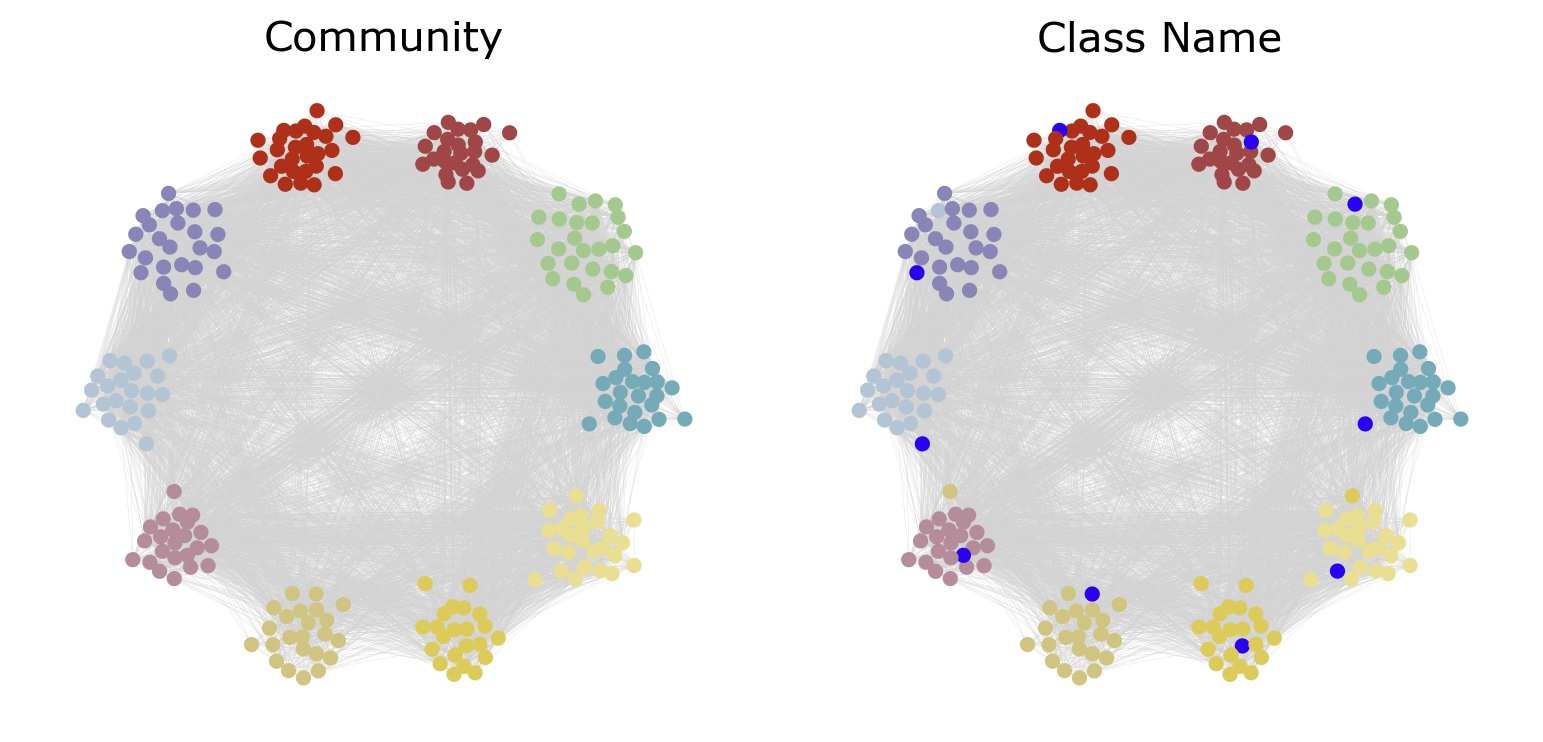

In [93]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
import networkx as nx
fig = plt.figure(figsize=(8, 4))
widths = [4, 4]
heights = [4]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)

colors = ['#75AAB8', '#A3C98E', '#A04646', '#AE3019', '#8985B7', '#B3C4D4', 
          '#B58C9A', '#CFC580', '#DCCB59', '#E8DF92', "#2900F2"]
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
### Color
n_bin = givenNumGroup
cmap = LinearSegmentedColormap.from_list("my_cmap", colors[:-1], N=n_bin)
color = cmap(np.linspace(0, 1, n_bin))
### Position
proj_graph = nx.from_scipy_sparse_array(hgx_hypergraph.adjacency_matrix())
node_community = {i:reordered_partition[i] for i in range(ehg.n)}
# pos = nx.spring_layout(proj_graph, k=1, iterations=100)
pos = community_layout(proj_graph, node_community)
draw_communities(hypergraph=hgx_hypergraph, u=u_partition, col=color, ax=ax, pos=pos,
                 node_size=0.03, with_node_labels=False, scale=2, edge_width=0.1, wedge_width=0,
                 title='Community')
# ticks = n_bin * ((1/(2*(n_bin))) + np.arange(n_bin) * (1/(n_bin)))
# cbar = plt.colorbar(ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_bin)), ticks=ticks, label='Class', ax=ax)
# cbar.ax.set_yticklabels(meta_labels)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
### Color
n_bin = len(meta_labels)
cmap = LinearSegmentedColormap.from_list("my_cmap", colors, N=n_bin)
# cmap = mpl.colormaps['tab10']
color = cmap(np.linspace(0, 1, n_bin))
### Position
# proj_graph = nx.from_scipy_sparse_array(hgx_hypergraph.adjacency_matrix())
# node_community = {i:meta_labels.index(meta[i]) for i in range(ehg.n)}
# pos = nx.spring_layout(proj_graph, k=1, iterations=100)
# pos = community_layout(proj_graph, node_community)
draw_communities(hypergraph=hgx_hypergraph, u=u_meta, col=color, ax=ax, pos=pos,
                 node_size=0.03, with_node_labels=False, scale=2, edge_width=0.1, wedge_width=0,
                 title='Class Name')
save_path = f"./_Figure/Hyper/" + f"Primary_school_HyperBH.pdf"
# plt.tight_layout()
# plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=None)
plt.savefig(save_path, dpi=600)

C:\Users\24391\AppData\Local\Temp\ipykernel_17852\2313616539.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


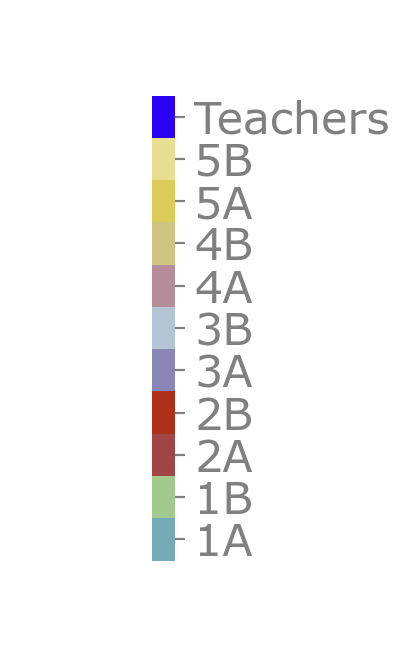

In [91]:
fig = plt.figure(figsize=(1, 4))
ax = fig.add_subplot()
ax.spines[['left', 'bottom']].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ticks = n_bin * ((1/(2*(n_bin))) + np.arange(n_bin) * (1/(n_bin)))
cbar = plt.colorbar(ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_bin)), ticks=ticks, label='', ax=ax)
cbar.ax.set_yticklabels(meta_labels)
cbar.outline.set_visible(False)

save_path = f"./_Figure/Hyper/" + f"Primary_school_HyperBH_Colorbar.pdf"
plt.tight_layout()
# plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=None)
plt.savefig(save_path, dpi=600, bbox_inches='tight')

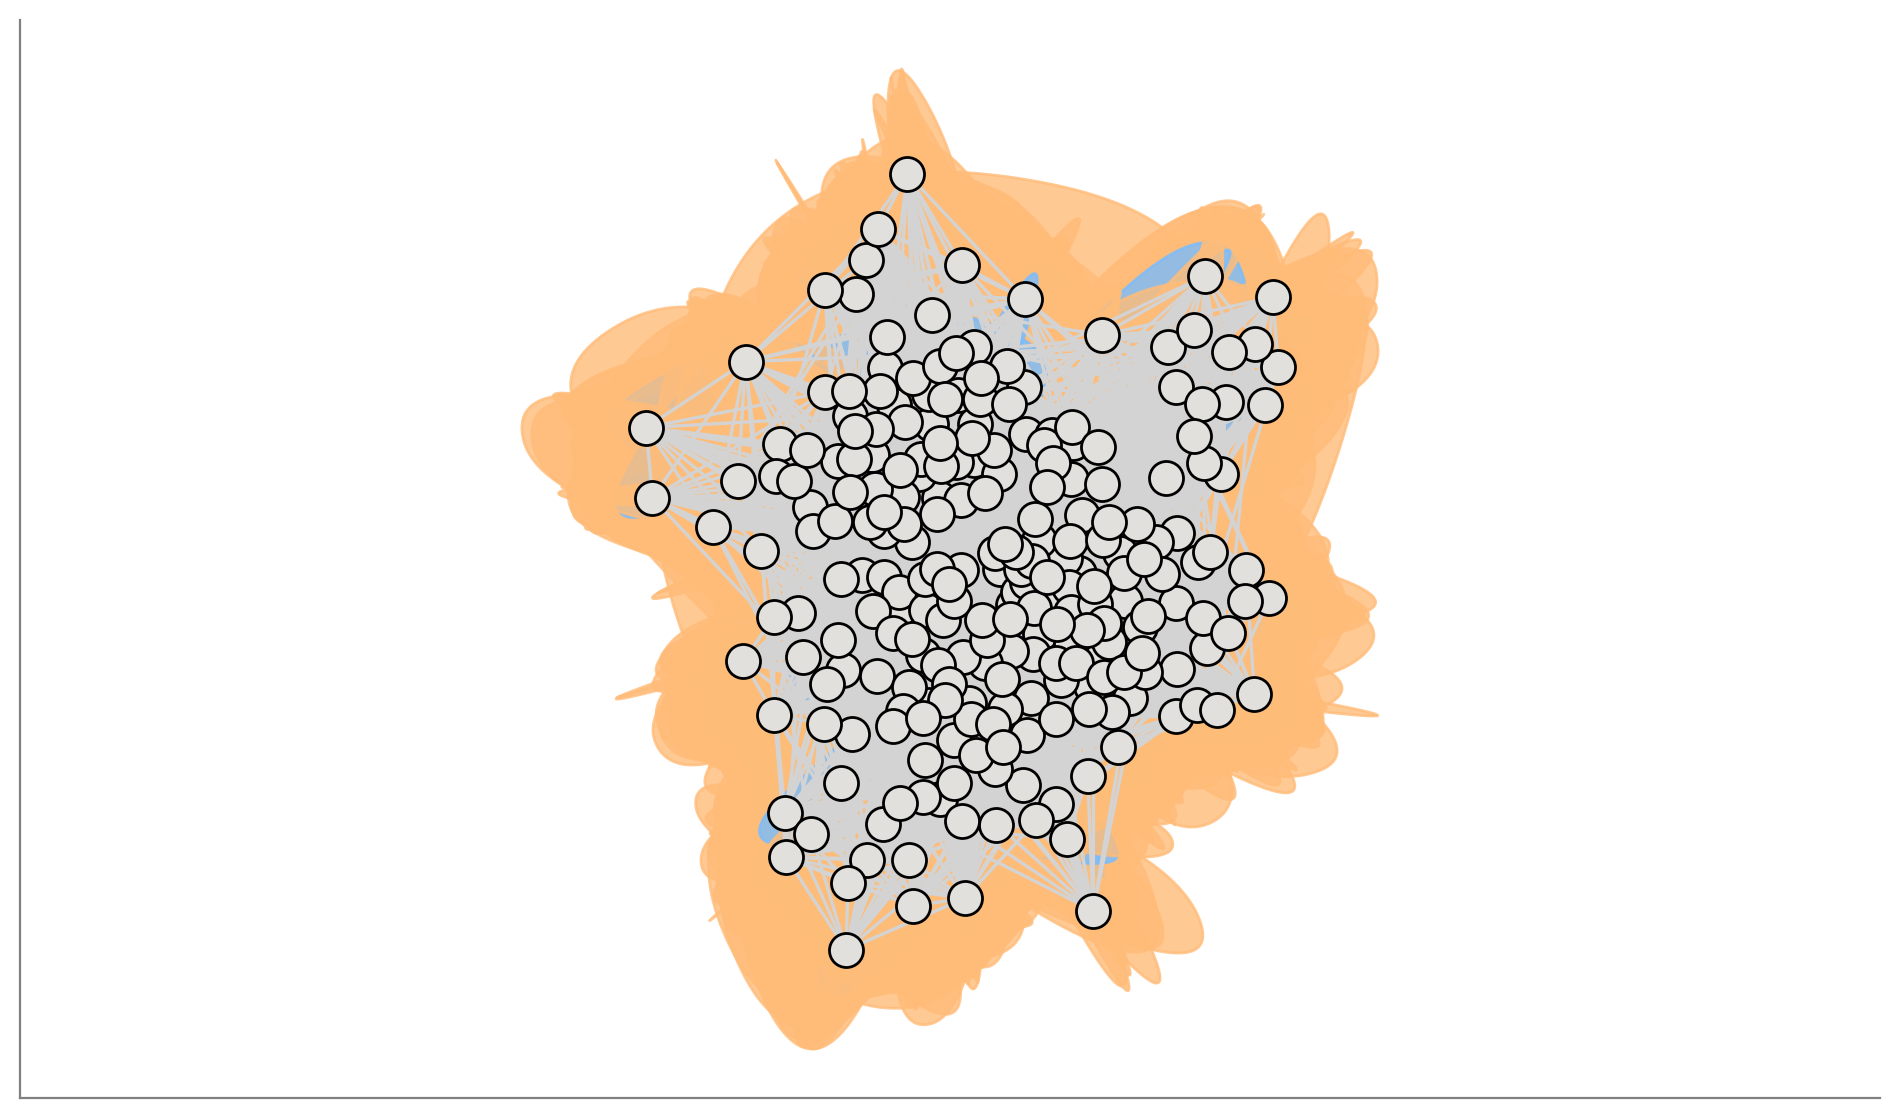

In [23]:
draw_hypergraph(hgx_hypergraph)

In [ ]:
colors = ['#75AAB8', '#A3C98E', '#A04646', '#AE3019', '#8985B7', '#B3C4D4', '#B58C9A', '#CFC580', '#DCCB59', '#E8DF92', "#2900F2"]
colors = ['#B3C4D4', '#75AAB8', '#A3C98E', '#A04646', '#AE3019', '#B58C9A', '#CFC580', '#DCCB59', '#E8DF92']

## CM

In [13]:
cm, cm_df = visualMetaCM(reordered_partition, meta)
print(cm)

[[23.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 25.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. 23.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 26.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 23.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 21.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. 21.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1. 22.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 21.  1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 24.]
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]]


[[23.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 25.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. 23.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 26.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 23.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 21.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. 21.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1. 22.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 21.  1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 24.]
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]]
[0 1 2 3 4 5 6 7 8 9]


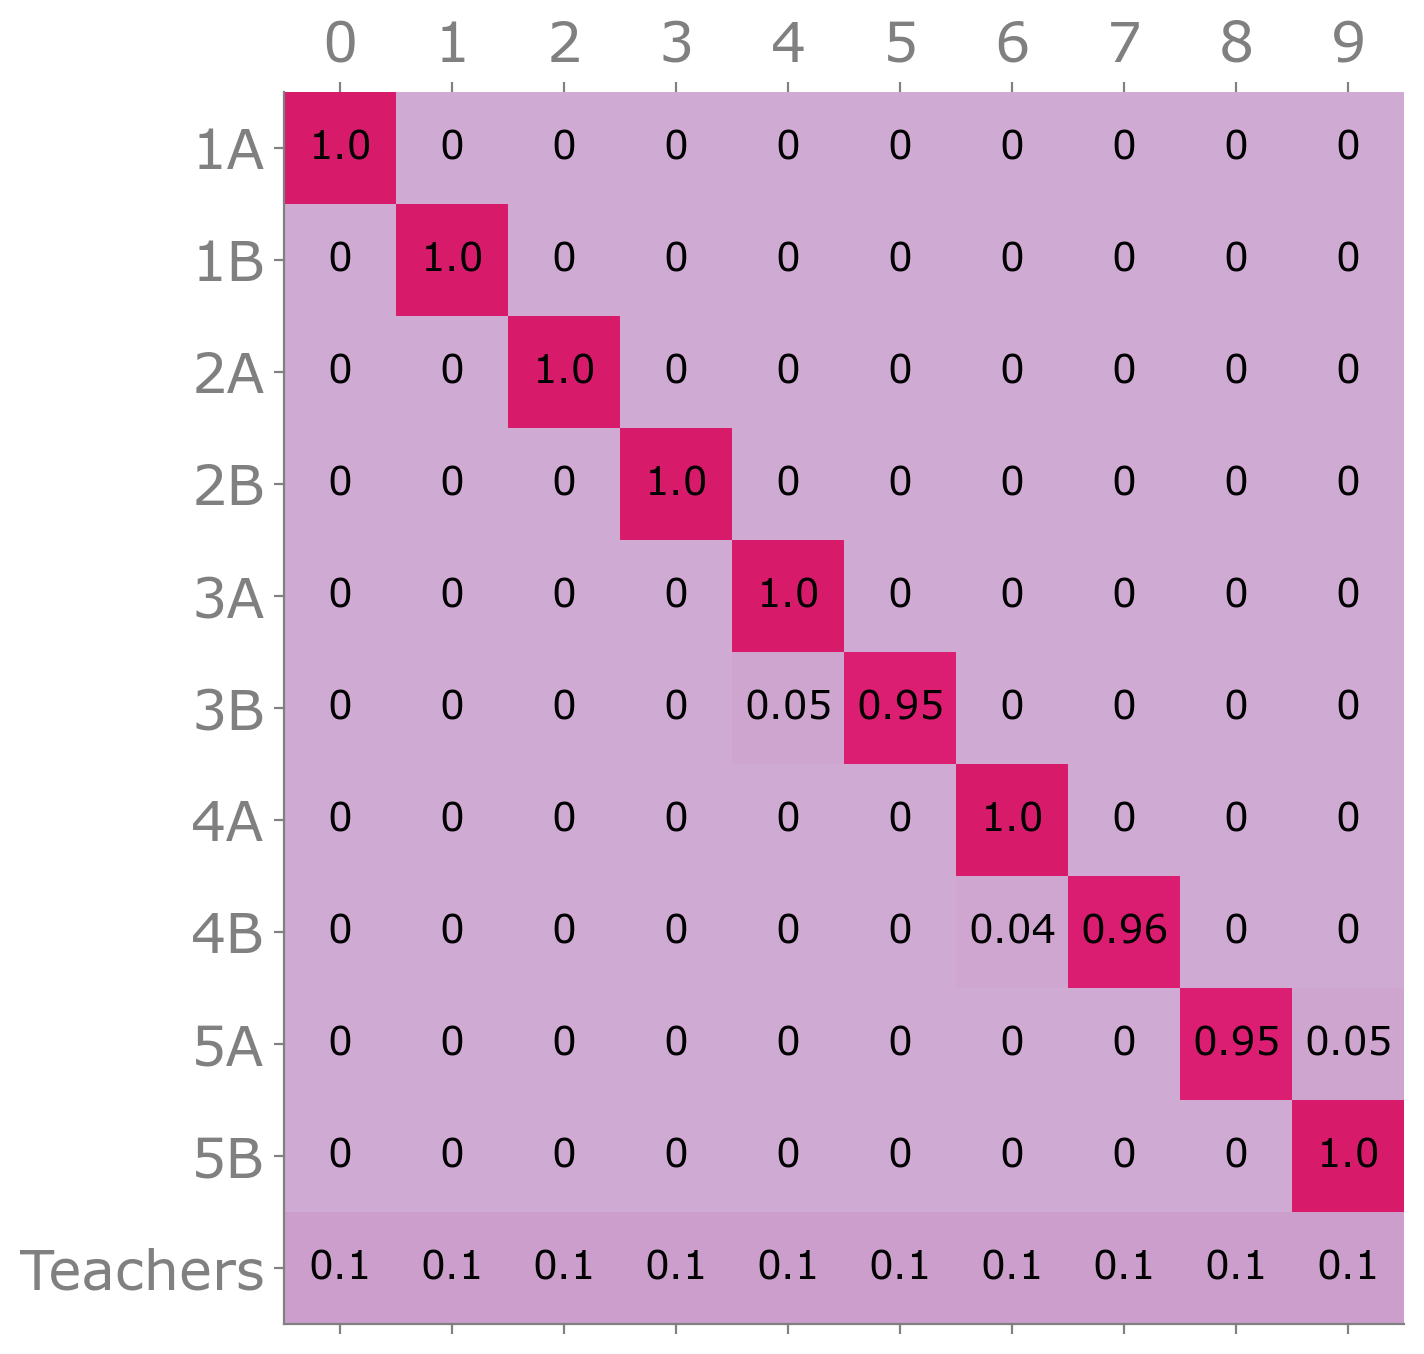

In [20]:
fig = plt.figure(figsize=(8, 8))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
# cmap = mpl.colormaps["seismic_r"]
cmap = mpl.colormaps["PuRd"]
cmap = truncate_colormap(cmap, 0.3, 0.7)
rowsum = np.sum(cm, axis=1)
rowsum = rowsum.reshape(-1, 1)
rowsum = np.repeat(rowsum, np.shape(cm)[1], axis=1)
norm_cm = np.round(cm / rowsum, 2)
print(cm)
ax.matshow(norm_cm, cmap=cmap, vmin=0, vmax=np.max(norm_cm))
for i in range(np.shape(cm)[0]):
    for j in range(np.shape(cm)[1]):
        c = norm_cm[i,j]
        ax.text(j, i, str(np.round(c, 3) if c != 0 else 0), va='center', ha='center', fontsize=14)
ax.set_xticks(np.arange(0, np.shape(cm)[1]), np.arange(0, np.shape(cm)[1]), fontsize=20)
ax.set_yticks(np.arange(0, np.shape(cm)[0]), meta_labels, fontsize=20)
print(ax.get_xticks())
save_path = "./_Figure/Hyper/" + "FigurePrimaryCm.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)